In [11]:
from agnpy.emission_regions import Cone
import astropy.units as u
from agnpy.spectra import ParticleDistribution
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2
from agnpy.spectra.spectra import ExpCutoffPowerLaw
from agnpy.synchrotron import *
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
import numpy as np
from astropy.constants import c, sigma_T, m_e, e, mu0
#e = e.gauss
mec2 = mec2.to('eV')
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt
from astropy.constants import c, sigma_T, m_e, e, mu0
from scipy.sparse import diags
from matplotlib import cycler, rcParams
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2

In [12]:
n_e_c = ExpCutoffPowerLaw(k = 6604 , mass=m_e, p=2, gamma_min = 1, gamma_max= 10958000, gamma_c= 109580 )

In [85]:
gamma = np.logspace(np.log(1),np.log(1e6),100)

In [87]:
n_e_c(gamma)[0]

6603.939733803004

# Temporal Evolution

In [10]:
import numpy as np
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt
from astropy.constants import c, sigma_T, m_e, e, mu0
from scipy.sparse import diags
from matplotlib import cycler, rcParams
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2

def gamma_loss(gamma):
    B = 0.363 * u.G
    u_B = ((B_to_cgs(B)**2)/(8*np.pi)).to('erg cm-3')
    prefactor = (4 * c.cgs * sigma_T.cgs) / (3 * m_e.cgs * c.cgs * c.cgs )
    value = prefactor * (u_B) * np.power(gamma, 2)
    return -value.to("s-1")

class ChangCooperSolver_time:
    def __init__(
        self,
        gamma_min,
        gamma_max,
        n_gamma,
        t_max_ev,
        n_t

    ):
        """class implementing the Chang and Cooper scheme in Chaiberge and Ghisellini (1998):

        Parameters
        ----------
        gamma_min : float
            minimum Lorentz factor of the electorn distribution
        gamma_max : float
            maximum Lorentz factor of the electron distribution
        n_gamma : int
            number of steps in the Lorentz factor grid
        t_max_ev : `~astropy.Units.Quantity`
            maximum time of the evolution
        n_t : int
            number of time steps
        t_max_inj : `~astropy.Units.Quantity`
            maximum time of injection
        t_esc : `~astropy.Units.Quantity`
            escape time
        injection_dict : dict
            dictionary with injection specifications (spectrum and maximum injection time)
        """
        self.gamma_min = gamma_min
        self.gamma_max = gamma_max
        self.n_gamma = n_gamma
        _gamma = np.logspace(np.log10(gamma_min), np.log10(gamma_max), n_gamma)
        # $\gamma_{i \pm 1/2}$ in Chiaberge et al. (1998)
        self.gamma_midpts = _gamma[::2]
        # $\delta gamma_i$ in Chiaberge et al. (1998)
        self.delta_gamma = self.gamma_midpts[:-1] - self.gamma_midpts[1:]
        # $\gamma_i$ in Chiaberge et al. (1998)
        self.gamma = _gamma[1:-1:2]
        self.t_max_ev = t_max_ev.to('s')
        self.delta_t = t_max_ev/n_t

    @property
    def gamma_dot_midpts(self):
        return gamma_loss(self.gamma_midpts)

    @property
    def V2(self):
        loss_term = (
            self.delta_t * self.gamma_dot_midpts[:-1]
        ).decompose().value / self.delta_gamma
        return 1  + loss_term

    @property
    def V3(self):
        return (
            -(self.delta_t * self.gamma_dot_midpts[1:]).decompose().value
            / self.delta_gamma
        )

    @property
    def chang_cooper_matrix(self):
        return diags([self.V2, self.V3], offsets=[0, 1]).toarray()

    def run(self):
        """solve the temporal evolution, return the result at each step"""
        print("solving Chang and Cooper equation iteratively!")
        solutions = dict()
        elapsed_time = 0 * u.s
        # initial electron distributions, suppose it's 0 everywhere at the first step
        N_prev = n_e_c(self.gamma) 
        while elapsed_time < self.t_max_ev:
            # add the source term only for times before t_max_injection, strip units
            # compute electron distribution at next time step, units have been stripped
            N_next = np.linalg.solve(self.chang_cooper_matrix, N_prev)
            print("check correctness of solution...")
            print(np.allclose(np.dot(self.chang_cooper_matrix, N_next), N_prev))
            # store solution
            solutions[f"{elapsed_time}"] = N_next * u.Unit("cm-3")
            # the solution becomes the spectrum at the next step
            N_prev = N_next
            elapsed_time += self.delta_t
        return solutions

In [48]:
cc_solver_time = ChangCooperSolver_time(
    gamma_min=1,
    gamma_max=1e7,
    n_gamma=200,
    t_max_ev= 9265669.3*u.h, #equiavelnt to 1e21 cm
    n_t = 6 ,
)
solutions = cc_solver_time.run()

solving Chang and Cooper equation iteratively!
check correctness of solution...
True
check correctness of solution...
True
check correctness of solution...
True
check correctness of solution...
True
check correctness of solution...
True
check correctness of solution...
True
check correctness of solution...
True


In [49]:
#getting Radius at each time step, to obtain number of electrons instead of density
distances = []
for idx, key in enumerate(solutions.keys()):
    t = u.Quantity(key)
    d = c.cgs * t
    distances.append(d.value)
distances = np.array(distances) * u.cm
R_x = 7.32 * 1e15 * u.cm+ distances * np.tan(9.7 * u.deg)


In [77]:
distances

<Quantity [1.00000000e+00, 1.27427499e+01, 1.62377674e+02, 2.06913808e+03,
           2.63665090e+04, 3.35981829e+05, 4.28133240e+06, 5.45559478e+07,
           6.95192796e+08, 8.85866790e+09, 1.12883789e+11, 1.43844989e+12,
           1.83298071e+13, 2.33572147e+14, 2.97635144e+15, 3.79269019e+16,
           4.83293024e+17, 6.15848211e+18, 7.84759970e+19] cm>

In [76]:
for idx, key in enumerate(solutions):
    label = (u.Quantity(key).to("s"))*c.cgs
    y =  solutions[key]*R_x[idx]**2
    print(idx)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18


[2.08886473e+35 1.38713534e+35 9.13069881e+34 5.96147962e+34
 3.86348312e+34 2.48710660e+34 1.59150915e+34 1.01301832e+34
 6.41789843e+33 4.04936354e+33 2.54581023e+33 1.59556175e+33
 9.97308522e+32 6.21916684e+32 3.87043927e+32 2.40455270e+32
 1.49162212e+32 9.24110518e+31 5.71882761e+31 3.53569111e+31
 2.18414901e+31 1.34827559e+31 8.31771154e+30 5.12851395e+30
 3.16060112e+30 1.94697857e+30 1.19890385e+30 7.37995296e+29
 4.54129398e+29 2.79363625e+29 1.71802190e+29 1.05622791e+29
 6.49165541e+28 3.98857939e+28 2.44984957e+28 1.50421435e+28
 9.23245367e+27 5.66430605e+27 3.47360505e+27 2.12910465e+27
 1.30428213e+27 7.98500628e+26 4.88511856e+26 2.98629910e+26
 1.82392445e+26 1.11287636e+26 6.78263175e+25 4.12855722e+25
 2.50943844e+25 1.52283668e+25 9.22441604e+24 5.57611877e+24
 3.36293669e+24 2.02288119e+24 1.21322724e+24 7.25221291e+23
 4.31887880e+23 2.56115028e+23 1.51156508e+23 8.87318014e+22
 5.17713515e+22 2.99994567e+22 1.72488217e+22 9.83062847e+21
 5.54713916e+21 3.094846

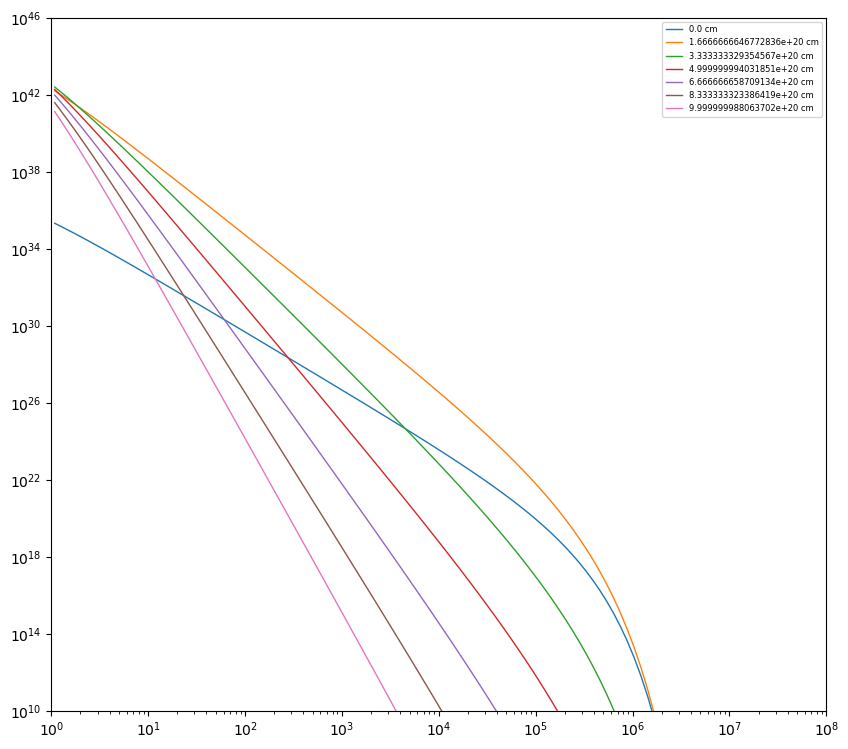

In [53]:
fig, ax = plt.subplots(figsize=(10, 9))

for idx, key in enumerate(solutions):
    label = (u.Quantity(key).to("s"))*c.cgs
    y =  solutions[key]*R_x[idx]**2
    print(y)
    

    ax.loglog(
        cc_solver_time.gamma,
        y,
        lw=1,
        label=label,
    )

plt.legend(fontsize=6)
ax.set_xlim(1, 1e8)
ax.set_ylim(1e10, 1e46)
plt.show()

In [54]:
N_e_tg_list = []

for idx, key in enumerate(solutions):
    values = solutions[key] * (R_x[idx]**2)
    N_e_tg_list.append(values)

N_e_tg = u.Quantity(N_e_tg_list)

# Spatial Evolution

In [78]:
x = np.logspace(np.log10(1), np.log10(1e21), 100) * u.cm

In [79]:
def gamma_loss(gamma):
    B = 0.363 * u.G
    u_B = ((B_to_cgs(B)**2)/(8*np.pi)).to('erg cm-3')
    prefactor = (4 * c.cgs * sigma_T.cgs) / (3 * m_e.cgs * c.cgs * c.cgs )
    value = prefactor * (u_B) * np.power(gamma, 2)
    return -value.to("s-1")

class ChangCooperSolver:
    def __init__(
        self,
        gamma_min,
        gamma_max,
        n_gamma,
        x,
        n_e

    ):
        """class implementing the Chang and Cooper scheme in Chaiberge and Ghisellini (1998):

        Parameters
        ----------
        gamma_min : float
            minimum Lorentz factor of the electorn distribution
        gamma_max : float
            maximum Lorentz factor of the electron distribution
        n_gamma : int
            number of steps in the Lorentz factor grid
        t_max_ev : `~astropy.Units.Quantity`
            maximum time of the evolution
        n_t : int
            number of time steps
        t_max_inj : `~astropy.Units.Quantity`
            maximum time of injection
        t_esc : `~astropy.Units.Quantity`
            escape time
        injection_dict : dict
            dictionary with injection specifications (spectrum and maximum injection time)
        """
        self.gamma_min = gamma_min
        self.gamma_max = gamma_max
        self.n_gamma = n_gamma
        self.n_e = n_e
        _gamma = np.logspace(np.log10(gamma_min), np.log10(gamma_max), n_gamma)
        # $\gamma_{i \pm 1/2}$ in Chiaberge et al. (1998)
        self.gamma_midpts = _gamma[::2]
        # $\delta gamma_i$ in Chiaberge et al. (1998)
        self.delta_gamma = self.gamma_midpts[:-1] - self.gamma_midpts[1:]
        # $\gamma_i$ in Chiaberge et al. (1998)
        self.gamma = _gamma[1:-1:2]
        self.x = x.to('cm')
        self.t = x/c.cgs

    @property
    def gamma_dot_midpts(self):
        return gamma_loss(self.gamma_midpts)

    def run(self):
        """solve the temporal evolution, return the result at each step"""
        print("solving Chang and Cooper equation iteratively!")
        solutions = dict()
        N_prev = self.n_e(self.gamma) 
        for i in range(len(self.t)-1):
            elapsed_time = self.t[i]
            dt = (self.t[i+1] - self.t[i]).to('s')
            loss_term = (dt * self.gamma_dot_midpts[:-1]).decompose().value / self.delta_gamma
            V2 = 1 + loss_term
            V3 = -(dt * self.gamma_dot_midpts[1:]).decompose().value / self.delta_gamma
            cc_matrix = diags([V2, V3], offsets=[0, 1]).toarray()
            N_next = np.linalg.solve(cc_matrix, N_prev) 
            solutions[f"{elapsed_time}"] = N_next * u.Unit("cm-3")
            N_prev = N_next
        return solutions

In [80]:
cc_solver = ChangCooperSolver(
    gamma_min=1,
    gamma_max=1e7,
    n_gamma=200,
    x = x ,
    n_e = n_e_c
)
solutions = cc_solver.run()

solving Chang and Cooper equation iteratively!


In [81]:
distances = []
for idx, key in enumerate(solutions.keys()):
    t = u.Quantity(key)
    d = c.cgs * t
    distances.append(d.value)
distances = np.array(distances) * u.cm
R_x = 7.32 * 1e15 * u.cm+ distances * np.tan(9.7 * u.deg)


In [82]:
R_x

<Quantity [7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000000e+15, 7.32000000e+15, 7.32000000e+15, 7.32000000e+15,
           7.32000001e+15, 7.32000001e+15, 7.32000002e+15, 7.32000003e+15,
           7.32000005e+15, 7.32000009e+15, 7.32000014e+15, 7.32000023e+15,
           7.32000037e+15, 7.32000060e+15, 7.32000098e+15, 7.32000159e+15,
           7.32000260e+15, 7.32000423e+15, 7.32000690e+15, 7.32001125e+15,
           7.32001833e+15

0.9999999999999999 cm
1.6297508346206442 cm
2.6560877829466865 cm
4.328761281083058 cm
7.054802310718643 cm
11.497569953977356 cm
18.73817422860384 cm
30.538555088334157 cm
49.770235643321115 cm
81.11308307896873 cm
132.19411484660287 cm
215.44346900318845 cm
351.1191734215131 cm
572.236765935022 cm
932.60334688322 cm
1519.9110829529347 cm
2477.0763559917114 cm
4037.017258596554 cm
6579.332246575683 cm
10722.672220103232 cm
17475.28400007683 cm
28480.35868435805 cm
46415.88833612782 cm
75646.3327554629 cm
123284.67394420657 cm
200923.3002565046 cm
327454.9162877732 cm
533669.9231206313 cm
869749.0026177834 cm
1417474.1629268047 cm
2310129.7000831626 cm
3764935.806792471 cm
6135907.273413176 cm
10000000.0 cm
16297508.346206432 cm
26560877.829466894 cm
43287612.810830615 cm
70548023.10718645 cm
114975699.53977357 cm
187381742.2860387 cm
305385550.88334125 cm
497702356.4332114 cm
811130830.789689 cm
1321941148.4660287 cm
2154434690.0318866 cm
3511191734.2151275 cm
5722367659.35022 cm
9326

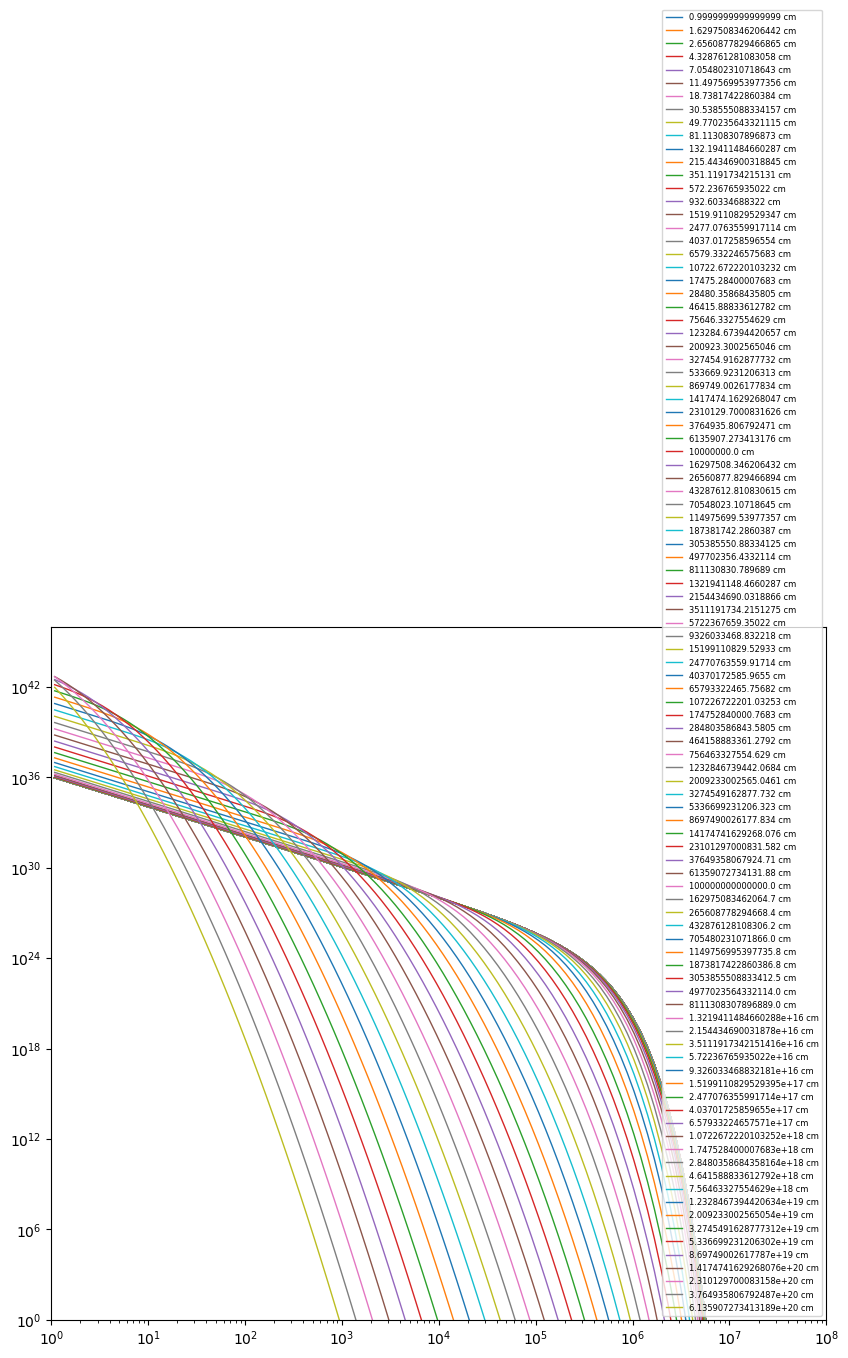

In [83]:
fig, ax = plt.subplots(figsize=(10, 9))

for idx, key in enumerate(solutions):
    label = (u.Quantity(key).to("s"))*c.cgs
    y =  solutions[key] * np.pi *R_x[idx]**2
    print(label)
    

    ax.loglog(
        cc_solver.gamma,
        y,
        lw=1,
        label=label,
    )

plt.legend(fontsize=6)
ax.set_xlim(1, 1e8)
ax.set_ylim(1, 1e46)
plt.show()

In [84]:
N_e_tg_list = []

for idx, key in enumerate(solutions):
    values = solutions[key] * np.pi * R_x[idx]**2
    N_e_tg_list.append(values)

N_e_tg = u.Quantity(N_e_tg_list)

In [85]:
np.trapz(N_e_tg[0,:])

<Quantity 2.94356649e+36 1 / cm>

In [86]:
np.trapz(N_e_tg[10,:])

<Quantity 2.94356649e+36 1 / cm>

In [88]:
np.trapz(N_e_tg[50,:])

<Quantity 2.94357204e+36 1 / cm>